In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader

import kagglehub

import time

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


c:\Users\Michael\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#adjustable for experiment

from Classifiers import ControlClassifier, EncodedClassifier

num_epochs   = 100
lr           = 1e-3 #same lr for both to reduce confounding variables
batch_size   = 128
num_classes  = 8    #hard coded pain to fix for no gain
latent_dim   = 256

criterion = nn.CrossEntropyLoss()

control_classifier = ControlClassifier(num_classes).to(device)
encoded_classifier = EncodedClassifier(latent_dim, num_classes).to(device)


control_optimizer = optim.Adam(control_classifier.parameters(), lr=lr)
encoded_optimizer = optim.Adam(encoded_classifier.parameters(), lr=lr)

In [ ]:
#importing images
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_dataset = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")
full_dataset += '/RetinalOCT_Dataset/RetinalOCT_Dataset' 
train_dataset = ImageFolder(
    root=full_dataset+'/train',
    transform=transform
)

train_loader = DataLoader(
   dataset=train_dataset,
   batch_size=batch_size,
   shuffle=True,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

val_dataset = ImageFolder(
    root= full_dataset+'/val',
    transform=transform
)

#val
val_loader = DataLoader(
   dataset=val_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

#test
test_dataset = ImageFolder(
    root= full_dataset+'/test',
    transform=transform
)

test_loader = DataLoader(
   dataset=test_dataset,
   batch_size=batch_size,
   shuffle=False,
   #increases compute speed
   num_workers=8,
   pin_memory=True
)

In [4]:
#training control
start_time = time.perf_counter()

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        output = control_classifier(images)
        loss = criterion(output, labels)

        control_optimizer.zero_grad()
        loss.backward()
        control_optimizer.step()

        total_loss += loss.item()

        predicted = output.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    
    print(
        f"Epoch {epoch+1}: "
        f"Loss={avg_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%"
    )
    
end_time = time.perf_counter()

control_accuracy = accuracy
control_train_time = end_time - start_time

print(
    f"Results: Accuracy={control_accuracy:.2f}% "
    f"Training Duration={control_train_time:.6f} sec"
)

Epoch 1: Loss=3.7307, Accuracy=30.61%
Epoch 2: Loss=1.5311, Accuracy=37.80%
Epoch 3: Loss=1.4141, Accuracy=40.47%
Epoch 4: Loss=1.3228, Accuracy=43.42%
Epoch 5: Loss=1.2672, Accuracy=45.16%
Epoch 6: Loss=1.2635, Accuracy=45.47%
Epoch 7: Loss=1.2525, Accuracy=45.53%
Epoch 8: Loss=1.1580, Accuracy=48.99%
Epoch 9: Loss=1.1711, Accuracy=49.36%
Epoch 10: Loss=1.1420, Accuracy=51.53%
Epoch 11: Loss=1.1219, Accuracy=51.44%
Epoch 12: Loss=1.1092, Accuracy=52.02%
Epoch 13: Loss=1.0732, Accuracy=52.55%
Epoch 14: Loss=1.0533, Accuracy=54.08%
Epoch 15: Loss=1.0510, Accuracy=54.39%
Epoch 16: Loss=1.0381, Accuracy=55.04%
Epoch 17: Loss=1.0447, Accuracy=54.46%
Epoch 18: Loss=1.0301, Accuracy=55.66%
Epoch 19: Loss=0.9977, Accuracy=56.37%
Epoch 20: Loss=1.0404, Accuracy=55.02%
Epoch 21: Loss=0.9846, Accuracy=56.95%
Epoch 22: Loss=0.9809, Accuracy=57.39%
Epoch 23: Loss=0.9624, Accuracy=57.98%
Epoch 24: Loss=0.9365, Accuracy=59.63%
Epoch 25: Loss=0.9589, Accuracy=58.41%
Epoch 26: Loss=0.9421, Accuracy=59

In [ ]:
#Encoding images to latent space
from AutoEncoder import AutoEncoder

weights = torch.load("oct_autoencoder_model.pth", map_location=device)
ae = AutoEncoder()
ae.load_state_dict(weights)
encoder = ae.encoder.to(device)
encoder.eval()

start_time = time.perf_counter()

features = []
labels_list = []

with torch.no_grad():
    for images, batch_labels in train_loader:
        images = images.to(device)
        encoded = encoder(images).flatten(1)
        features.append(encoded.cpu())
        labels_list.append(batch_labels)

features = torch.cat(features)
all_labels = torch.cat(labels_list)

encode_time = time.perf_counter() - start_time

encoded_dataset = TensorDataset(features, all_labels)

encoded_loader = DataLoader(
    encoded_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(len(features), len(all_labels), f"{encode_time:.1f}s")

18400 18400 25.5s


In [6]:
#training encoded
start_time = time.perf_counter()

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0

    for encoded, labels in encoded_loader:
        encoded = encoded.to(device)
        labels = labels.to(device)

        outputs = encoded_classifier(encoded)
        loss = criterion(outputs, labels)

        encoded_optimizer.zero_grad()
        loss.backward()
        encoded_optimizer.step()

        total_loss += loss.item()

        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(encoded_loader)
    accuracy = 100 * correct / total
    end_time = time.perf_counter() - start_time

    print(
        f"Epoch {epoch+1}: "
        f"Loss={avg_loss:.4f}, "
        f"Accuracy={accuracy:.2f}%"
    )

end_time = time.perf_counter()

encoded_train_time = end_time - start_time
encoded_accuracy = accuracy

print(
    f"Results: Accuracy={encoded_accuracy:.2f}% "
    f"Train Duration={encoded_train_time:.6f} sec "
    f"Total Duration={encode_time+encoded_train_time} sec"
)

Epoch 1: Loss=1.2531, Accuracy=44.71%
Epoch 2: Loss=1.0227, Accuracy=54.46%
Epoch 3: Loss=0.9131, Accuracy=60.91%
Epoch 4: Loss=0.8500, Accuracy=64.03%
Epoch 5: Loss=0.7974, Accuracy=66.66%
Epoch 6: Loss=0.7559, Accuracy=68.65%
Epoch 7: Loss=0.7189, Accuracy=70.43%
Epoch 8: Loss=0.6919, Accuracy=71.53%
Epoch 9: Loss=0.6581, Accuracy=73.30%
Epoch 10: Loss=0.6295, Accuracy=74.80%
Epoch 11: Loss=0.6033, Accuracy=75.90%
Epoch 12: Loss=0.5886, Accuracy=76.46%
Epoch 13: Loss=0.5641, Accuracy=77.72%
Epoch 14: Loss=0.5468, Accuracy=78.42%
Epoch 15: Loss=0.5241, Accuracy=79.39%
Epoch 16: Loss=0.5086, Accuracy=80.22%
Epoch 17: Loss=0.4899, Accuracy=80.59%
Epoch 18: Loss=0.4761, Accuracy=81.59%
Epoch 19: Loss=0.4546, Accuracy=82.44%
Epoch 20: Loss=0.4441, Accuracy=82.64%
Epoch 21: Loss=0.4360, Accuracy=83.01%
Epoch 22: Loss=0.4155, Accuracy=83.90%
Epoch 23: Loss=0.4147, Accuracy=83.91%
Epoch 24: Loss=0.3939, Accuracy=84.68%
Epoch 25: Loss=0.3802, Accuracy=85.33%
Epoch 26: Loss=0.3776, Accuracy=85

In [7]:
# stronger classifier nn weakens case for pre-encoded

print(
    f"Control Accuracy:     {control_accuracy:.2f}%  in {control_train_time:.1f}s\n"
    f"Pre-Encoded Accuracy: {encoded_accuracy:.2f}%  in {encode_time + encoded_train_time:.1f}s "
    f"(encode {encode_time:.1f}s + train {encoded_train_time:.1f}s)"
)

Control Accuracy:     73.52%  in 2574.7s
Pre-Encoded Accuracy: 98.60%  in 66.8s (encode 25.5s + train 41.3s)


In [8]:
torch.save(control_classifier.state_dict(), "control_classifier.pth")
torch.save(encoded_classifier.state_dict(), "encoded_classifier.pth")

In [ ]:
#test

#new model instance
from Classifiers import ControlClassifier
from Classifiers import EncodedClassifier

cweights = torch.load("control_classifier.pth", map_location=device)
eweights = torch.load("encoded_classifier.pth", map_location=device)

control_classifier = ControlClassifier()
encoded_classifier = EncodedClassifier()

control_classifier.load_state_dict(cweights)
encoded_classifier.load_state_dict(eweights)

control_classifier = control_classifier.to(device)
encoded_classifier = encoded_classifier.to(device)



control_classifier.eval()
encoded_classifier.eval()

control_correct = 0
encoded_correct = 0
total = 0

control_class_correct = {c: 0 for c in range(num_classes)}
encoded_class_correct = {c: 0 for c in range(num_classes)}
class_total = {c: 0 for c in range(num_classes)}

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        control_output = control_classifier(images)
        control_predict = control_output.argmax(1)
        control_correct += (control_predict == labels).sum().item()

        encoded_output = encoded_classifier(encoder(images).flatten(1))
        encoded_predict = encoded_output.argmax(1)
        encoded_correct += (encoded_predict == labels).sum().item()

        for label, c_pred, e_pred in zip(labels, control_predict, encoded_predict):
            l = label.item()
            class_total[l] += 1
            if l == c_pred.item():
                control_class_correct[l] += 1
            if l == e_pred.item():
                encoded_class_correct[l] += 1

        total += labels.size(0)

control_test_acc = 100 * control_correct / total
encoded_test_acc = 100 * encoded_correct / total

print(f"Control test accuracy: {control_test_acc:.2f}%")
print(f"Encoded test accuracy: {encoded_test_acc:.2f}%")
print()
print(f"{'Class':<10} {'Control':>10} {'Encoded':>10}")
for c in range(num_classes):
    name = test_dataset.classes[c]
    c_acc = 100 * control_class_correct[c] / class_total[c]
    e_acc = 100 * encoded_class_correct[c] / class_total[c]
    print(f"{name:<10} {c_acc:>9.2f}% {e_acc:>9.2f}%")

Control test accuracy: 50.82%
Encoded test accuracy: 69.25%

Class         Control    Encoded
AMD            99.71%     99.71%
CNV            19.71%     59.14%
CSR            60.29%     84.29%
DME            47.71%     57.71%
DR             43.43%     66.57%
DRUSEN         26.86%     52.86%
MH             35.14%     78.29%
NORMAL         73.71%     55.43%


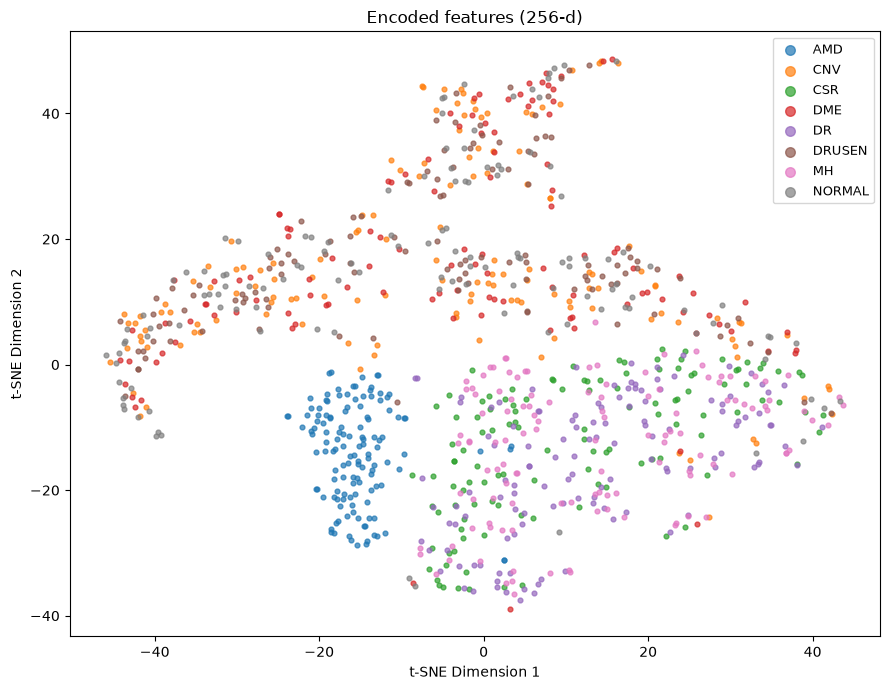

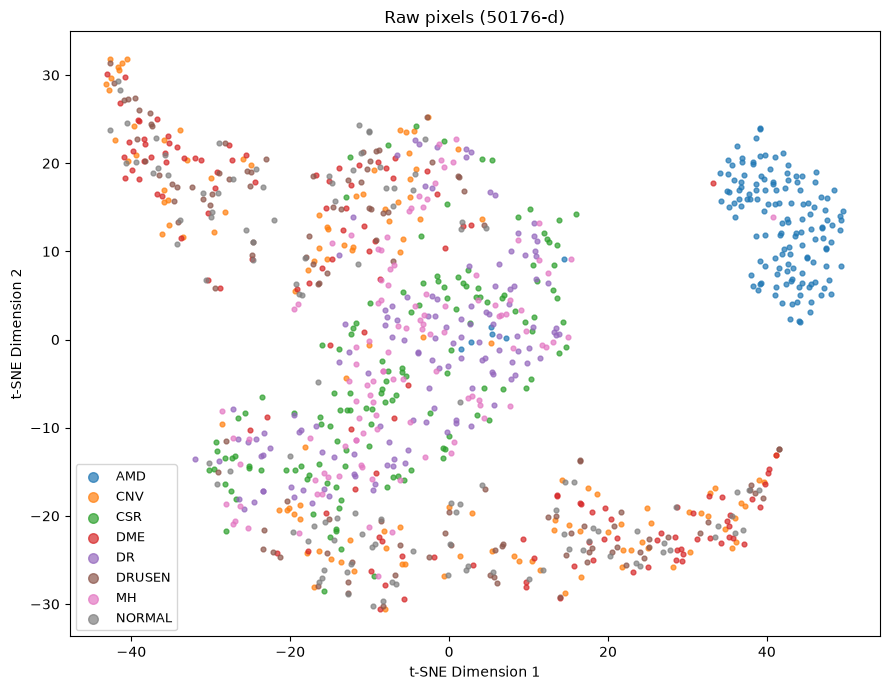

In [12]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

raw_x = []
raw_y = []
for images, batch_labels in train_loader:
    raw_x.append(images)
    raw_y.append(batch_labels)
    if len(raw_x) * batch_size >= 2000:
        break

raw_x = torch.cat(raw_x)
raw_y = torch.cat(raw_y)

def visualize_latent_space(feats, labs_tensor, class_names, n_samples=1000, title=""):
    idx = torch.randperm(len(feats))[:n_samples]
    vectors = feats[idx].cpu().numpy()
    labs = labs_tensor[idx].cpu().numpy()

    latent_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(vectors)

    plt.figure(figsize=(9, 7))
    for i, name in enumerate(class_names):
        m = labs == i
        plt.scatter(latent_2d[m, 0], latent_2d[m, 1], s=12, alpha=0.7, label=name)
    plt.legend(markerscale=2, fontsize=9)
    plt.title(title or "t-SNE of latent space")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.show()


visualize_latent_space(features, all_labels, train_dataset.classes,
                       title="Encoded features (256-d)")

visualize_latent_space(raw_x[:2000].flatten(1), raw_y[:2000], train_dataset.classes,
                       title="Raw pixels (50176-d)")